CST2101 BUSINESS INTELLIGENCE PROGRAMMING

Assignment 1. Scenario: Retail Store Sales Analysis

Ngan Nguyen | 041154207

Question 1. VARIABLES AND DATA TYPES

Write a Python program to:
- Load the CSV file.
- Print the total number of orders.
- Print the total revenue.
- Print the data type of each column.


In [1]:
# Load the CSV file
import pandas as pd
df = pd.read_csv("sales_data.csv")

In [2]:
print("Nguyen Ngan - 041154207")
print()
print(df)

Nguyen Ngan - 041154207

    OrderID Branch     Category     Product  Quantity  UnitPrice   OrderDate  \
0      1001  North  Electronics  Smartphone         1     699.99  2025-01-05   
1      1002  South     Clothing       Jeans         2      45.50  2025-01-05   
2      1003   West    Groceries        Milk         4       3.99  2025-01-06   
3      1004   East  Electronics      Laptop         1    1200.00  2025-01-07   
4      1005  North     Clothing     T-Shirt         3      15.00  2025-01-07   
5      1006  South    Groceries       Bread         2       2.50  2025-01-08   
6      1007   West  Electronics  Headphones         1     150.00  2025-01-09   
7      1008   East     Clothing      Jacket         1      89.00  2025-01-10   
8      1009  North    Groceries      Apples        10       0.50  2025-01-11   
9      1010  South  Electronics  Smartwatch         2     199.00  2025-01-12   
10     1011   West     Clothing       Socks         5       5.99  2025-01-13   
11     1012   E

In [3]:
# Print the total number of orders, total revenue, and the data type of each column

#Each row represents one order:
total_orders = len(df)

#Create a new column called "Revenue" by multiplying Quantity and UnitPrice for each row
#Then add up them together
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
total_revenue = df["Revenue"].sum()

print("Total number of orders: ", total_orders)
print(f"Total revenue: {total_revenue:.2f}")

#Display the data type of each column
print(f"Data type of each column: \n{df.dtypes}")


Total number of orders:  15
Total revenue: 3163.90
Data type of each column: 
OrderID         int64
Branch         object
Category       object
Product        object
Quantity        int64
UnitPrice     float64
OrderDate      object
CustomerID      int64
Revenue       float64
dtype: object


Question 2. CONTROL STATEMENTS

Using if-else statements, classify each order based on revenue (Quantity * UnitPrice) as:
- High Value if revenue > 500
- Medium Value if revenue between 200 and 500
- Low Value if revenue < 200

Store the classification in a new column OrderValueCategory.

(Topics: Control Statements, If-else, Pandas DataFrame operations)


In [4]:
#Create an empty list to store category labels for each order
categories = []

#Loop through each revenue value in the Revenue column
for revenue in df["Revenue"]:
    #If revenue > 500: classify as High Value
    if revenue > 500:
        categories.append("High Value")
        
    #If 200<revenue<500: classify as Medium Value
    elif revenue >= 200 and revenue <= 500:
        categories.append("Medium Value")
        
    #Otherwise, classify as Low Value
    else:
        categories.append("Low Value")

#Add the new category list as a new column in the DataFrame
df["OrderValueCategory"] = categories

print(df[["OrderID", "Revenue", "OrderValueCategory"]])

    OrderID  Revenue OrderValueCategory
0      1001   699.99         High Value
1      1002    91.00          Low Value
2      1003    15.96          Low Value
3      1004  1200.00         High Value
4      1005    45.00          Low Value
5      1006     5.00          Low Value
6      1007   150.00          Low Value
7      1008    89.00          Low Value
8      1009     5.00          Low Value
9      1010   398.00       Medium Value
10     1011    29.95          Low Value
11     1012    13.50          Low Value
12     1013   350.00       Medium Value
13     1014    65.00          Low Value
14     1015     6.50          Low Value


Question 3. LOOPS

Using a for loop, create a dictionary showing total revenue per branch. The dictionary should have branch names as keys and total revenue as values.

(Topics: For statement, Dictionaries, Looping)


In [5]:
#Create an empty dictionary to store total revenue for each branch
total_revenue_per_branch = {}

#Loop through each unique branch name in the Branch column
for branch in df["Branch"].unique():
    #Filter rows for the current branch and calculate the total revenue
    total_revenue = df[df["Branch"] == branch]["Revenue"].sum()
    #Store the result in the dictionary (key = branch, value = total revenue)
    total_revenue_per_branch[branch] = total_revenue
    
print(f"Total revenue per branch: \n{total_revenue_per_branch}")

#Convert dictionary into a table, while sort Total Revenue descendingly
table = pd.DataFrame(list(total_revenue_per_branch.items()), columns=["Branch", "Total Revenue"])
table = table.sort_values(by="Total Revenue", ascending=False)
print(table)

Total revenue per branch: 
{'North': np.float64(1099.99), 'South': np.float64(559.0), 'West': np.float64(202.41000000000003), 'East': np.float64(1302.5)}
  Branch  Total Revenue
3   East        1302.50
0  North        1099.99
1  South         559.00
2   West         202.41


Question 4. FUNCTIONS

Write a Python function average_order_value(branch) that:
- Takes a branch name as input
- Returns the average order value for that branch

Test the function for at least 3 branches.

(Topics: Functions, Function Arguments, Pass by Value vs Reference, Scope)


In [6]:
def average_order_value(branch):
    #Filter the DataFrame to only rows that match the given branch, then return its average revenue
    branch_orders = df[df["Branch"] == branch]["Revenue"].mean()
    return branch_orders


In [7]:
print("South: ", average_order_value("South"))
print("East: ", average_order_value("East"))
print("West: ", average_order_value("West"))

South:  139.75
East:  434.1666666666667
West:  50.602500000000006


Question 5. EXCEPTION HANDLING

Implement exception handling when:
- Reading the CSV file (handle FileNotFoundError)
- Converting Quantity and UnitPrice to numeric (handle ValueError)
- Print an appropriate message for each exception.

(Topics: Try-catch, Standard exceptions, User-defined exception)


In [8]:
#Try to read the CSV file into a DataFrame, handle case if the file does not exist
try:
    df = pd.read_csv("sales_data.csv")
except FileNotFoundError:
    print("Error: Could not find the file")

#Convert Quantity and UnitPrice columns to numeric type before doing calculations   
try:
    df["Quantity"] = pd.to_numeric(df["Quantity"])
    df["UnitPrice"] = pd.to_numeric(df["UnitPrice"])
#Handle error if they're non-numeric values
except ValueError:
    print("Error: Quantity or UnitPrice has invalid values")
    
#Compute Revenue = Quantity × UnitPrice for each row
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print("File loaded successfully with valid data and numeric columns")

File loaded successfully with valid data and numeric columns


Question 6. DATA VISUALIZATION

Visualize the data using Python libraries:

1.	Bar chart of total revenue per branch using Matplotlib

2.	Pie chart of order distribution by category using Seaborn

3.	Line chart of monthly revenue trend using Plotly

(Topics: Matplotlib, Seaborn, Plotly, Data Visualization)

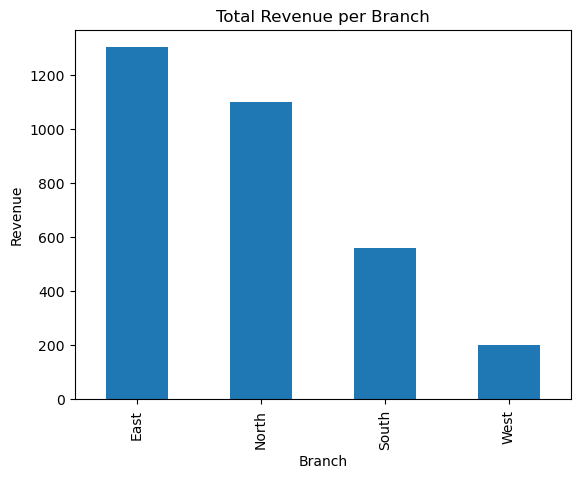

In [9]:
import matplotlib.pyplot as plt

#Calculate the total revenue for each branch after grouping them
total_revenue_per_branch = df.groupby("Branch")["Revenue"].sum()

#Plot the aggregated revenue as a bar chart
total_revenue_per_branch.plot(kind="bar")

#Add the label of title, x-axis, and y-axis, then show the chart
plt.title("Total Revenue per Branch")
plt.xlabel("Branch")
plt.ylabel("Revenue")
plt.savefig("total_revenue_per_branch.png")
plt.show()

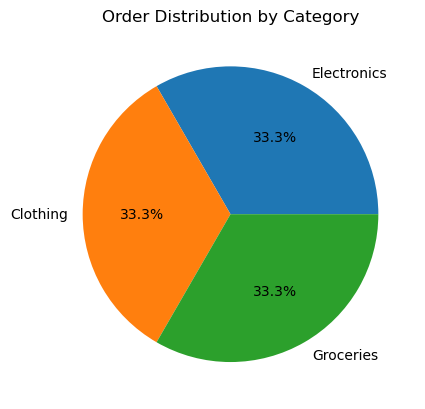

In [10]:
#Count the number of orders in each category and plot the distribution as a pie chart 
df["Category"].value_counts().plot(kind="pie", autopct="%1.1f%%")

#Add the label of the title and each category, then show the chart
plt.title("Order Distribution by Category")
plt.ylabel("")
plt.savefig("orders_by_category.png")
plt.show()

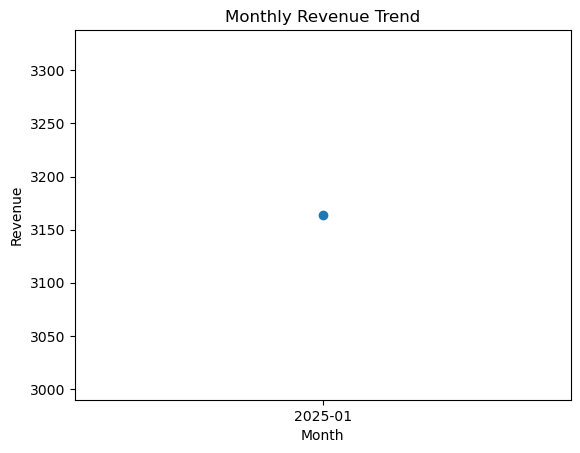

In [11]:
#Convert OrderDate column to datetime type to enable time-based operations
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

#Group data by month and calculate total revenue per month
monthly_revenue = df.groupby(df["OrderDate"].dt.to_period("M"))["Revenue"].sum()

#Convert PeriodIndex to string so it can be displayed properly on the x-axis
monthly_revenue.index = monthly_revenue.index.astype(str)

#Plot monthly revenue trend as a line chart
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")

#Add the label of the title, x-axis, y-axis, x-axis tick, then show the chart
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks()
plt.savefig("monthly_revenue.png")
plt.show()

Question 7. ADVANCED PYTHON CONCEPT

- Create a user-defined exception InvalidBranchError that is raised when a branch not in the dataset is passed to average_order_value()
- Demonstrate the exception handling by calling the function with an invalid branch name

(Topics: User-defined exception, Exception Handling, Functions)


In [13]:
# Create a new exception caused by the user when the invalid branch is entered
class InvalidBranchError(Exception):
    pass  # Custom exception class needs a pass statement if no additional code is needed

# Create a function to calculate average revenue by branch, raise an error if the branch doesn't in the dataset
def average_order_value(branch, df):
    if branch not in df["Branch"].values:
        raise InvalidBranchError("Branch not found")
    # If valid, compute and return the mean revenue for that branch
    return df[df["Branch"] == branch]["Revenue"].mean()

# Test with an invalid branch
try:
    print(average_order_value("HappyBranch", df))
except InvalidBranchError as error:
    print("Caught InvalidBranchError:", error)

Caught InvalidBranchError: Branch not found


Question 8. SUMMARY

Write a paragraph about the company's data, the insights derived from it, and any suggested improvements (50 - 100 words)


In [14]:
paragraph = (
    f"The dataset shows the January 2025 performance of RetailX, reflecting ${total_revenue:.2f} from {total_orders} orders, "
    "which were significantly influenced by a few large-value electronic transactions, while most transactions came from low-value items."
    "\nFor optimal growth, the very first thing the company should do is to impose strict data validation to ensure the accuracy of the data."
    "\nIn addition, although the East branch has the highest revenue, RetailX should take corrective action in the underperforming West branch."
    "\nThe company should review inventory and prioritize shipping higher-ticket electronics, such as laptops, to boost revenue rather than relying only on volume-driven sales."
)

print(paragraph)
print("Word count:", len(paragraph.split()))


The dataset shows the January 2025 performance of RetailX, reflecting $1302.50 from 15 orders, which were significantly influenced by a few large-value electronic transactions, while most transactions came from low-value items.
For optimal growth, the very first thing the company should do is to impose strict data validation to ensure the accuracy of the data.
In addition, although the East branch has the highest revenue, RetailX should take corrective action in the underperforming West branch.
The company should review inventory and prioritize shipping higher-ticket electronics, such as laptops, to boost revenue rather than relying only on volume-driven sales.
Word count: 98
